# Mathematical morphology

In [2]:
import numpy as np
import skimage as ski
import skimage.io as io
import matplotlib.pyplot as plt
import skimage.morphology as mo
import scipy.ndimage.morphology as smo
from skimage import img_as_float

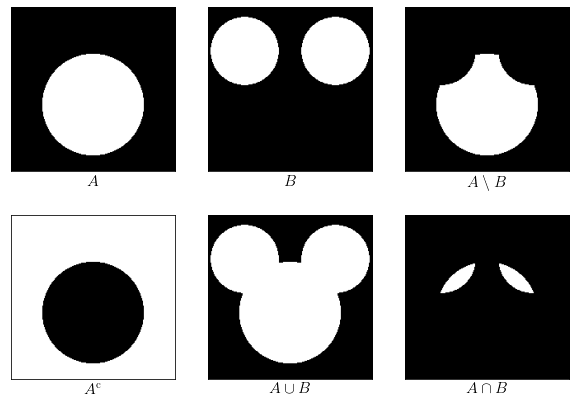

In [17]:
A = io.imread("A.png")
B = io.imread("B.png")
C = np.invert(A)
U = np.bitwise_or(A,B)
I = np.bitwise_and(A,B)
D = np.bitwise_and(A,np.invert(B))

def myplot(no, img, title):
    plt.subplot(2,3,no)
    plt.imshow(img, "gray")
    plt.rc('text', usetex=True)
    plt.rc('font', family='serif')
    plt.xlabel(title, size=16)
    plt.xticks([])
    plt.yticks([])

fig = plt.figure(figsize=(10,7))
myplot(1, A, "$A$")
myplot(2, B, "$B$")
myplot(3, D, "$A \setminus B$")
myplot(4, C, "$A^\mathrm{c}$")
myplot(5, U, "$A\cup B$")
myplot(6, I, "$A\cap B$")
plt.show()

# Ajoute un cadre autour de C
C[0,:] = 0
C[-1,:] = 0
C[:,0] = 0
C[:,-1] = 0

io.imsave("set-A.png", A)
io.imsave("set-B.png", B)
io.imsave("set-complement.png", C)
io.imsave("set-difference.png", D)
io.imsave("set-union.png", U)
io.imsave("set-intersection.png", I)

## Neighborhood and connectivity

In [9]:
import matplotlib as mpl
mpl.rcParams['xtick.bottom']      = False
mpl.rcParams['xtick.top']         = False
mpl.rcParams['xtick.labelbottom'] = False
mpl.rcParams['ytick.left']        = False
mpl.rcParams['ytick.right']       = False
mpl.rcParams['ytick.labelleft']   = False

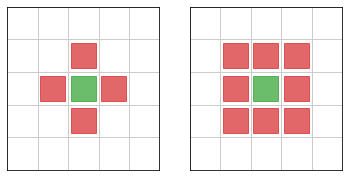

In [25]:
M, N = 7, 7  # Taille de l'image
m, n = 3, 3  # Pixel central

# Voisins
neighbors = [(m+1,n),   (m-1,n),   (m,n+1),   (m,n-1),
             (m+1,n+1), (m+1,n-1), (m-1,n+1), (m-1,n-1)]

fig, axs = plt.subplots(1, 2, figsize=(6,3))

for i in range(2):

    # Pixel central
    axs[i].plot(m, n, marker="s", color="C2", markersize=25, alpha=.7)
    
    # Représentation du voisinage
    for neighbor in neighbors[:4+4*i]:
        axs[i].plot(neighbor[0], neighbor[1], marker="s", color="C3", markersize=25, alpha=.7)

    # Grille
    axs[i].set_xticks(np.arange(.50+.02, N-1), minor=True) # hack : décalage de .02
    axs[i].set_yticks(np.arange(.50-.02, M-1), minor=True) # hack : décalage de .02
    axs[i].grid(which='minor', color='#cccccc', linewidth=1)

plt.savefig("neighborhood.svg", bbox_inches='tight')

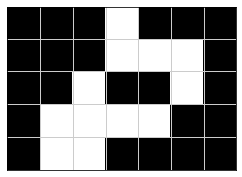

In [36]:
# Toy image
img = np.array([ \
    [0, 0, 0, 1, 0, 0, 0], \
    [0, 0, 0, 1, 1, 1, 0], \
    [0, 0, 1, 0, 0, 1, 0], \
    [0, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 0] ])
M, N = img.shape

# Dilation
fig, ax = plt.subplots(1, 1, figsize=(6,3))

ax.imshow(img, "gray")
    
ax.set_xticks(np.arange(.50+.02, N-1), minor=True) # hack : décalage de .02
ax.set_yticks(np.arange(.50-.02, M-1), minor=True) # hack : décalage de .02
ax.grid(which='minor', color='#cccccc', linewidth=1)

plt.savefig("connectivity.svg", bbox_inches='tight')

## Basic operators

In [3]:
import matplotlib as mpl
mpl.rcParams['xtick.bottom']      = False
mpl.rcParams['xtick.top']         = False
mpl.rcParams['xtick.labelbottom'] = False
mpl.rcParams['ytick.left']        = False
mpl.rcParams['ytick.right']       = False
mpl.rcParams['ytick.labelleft']   = False

def display(img, title, grid=True, sec=None):
    plt.imshow(img, "gray")
    plt.xlabel(title, size=16)
    
    # Centre de l'élément structurant
    if sec != None:
        plt.plot(sec[0], sec[1], marker="o")
    
    # Grille
    if grid:
        ax = plt.gca();
        M, N = img.shape
        ax.set_xticks(np.arange(.50+.02, N-1), minor=True) # hack : décalage de .02
        ax.set_yticks(np.arange(.50-.02, M-1), minor=True) # hack : décalage de .02
        ax.grid(which='minor', color='#cccccc', linewidth=1)

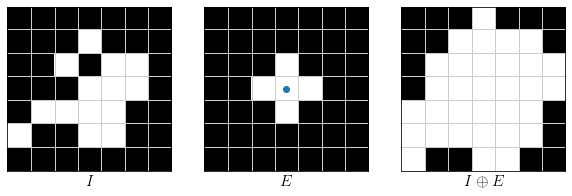

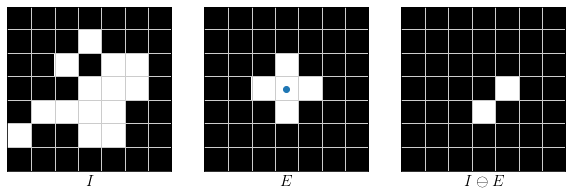

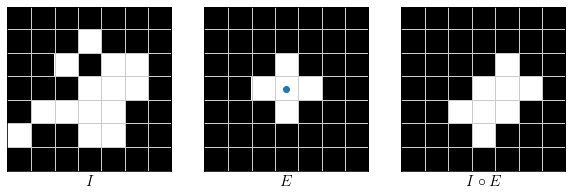

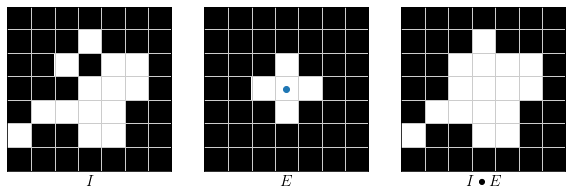

In [4]:
# Toy image
I = np.array([ \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 1, 0, 0, 0], \
    [0, 0, 1, 0, 1, 1, 0], \
    [0, 0, 0, 1, 1, 1, 0], \
    [0, 1, 1, 1, 1, 0, 0], \
    [1, 0, 0, 1, 1, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0] ])
# I = np.array([ \
#     [0, 0, 1, 0, 0, 0], \
#     [0, 1, 0, 1, 1, 0], \
#     [0, 0, 1, 1, 1, 0], \
#     [0, 1, 1, 1, 0, 0], \
#     [0, 0, 1, 1, 0, 0], \
#     [0, 0, 0, 0, 0, 0] ])

# Structuring element
E = np.array([ \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 1, 0, 0, 0], \
    [0, 0, 1, 1, 1, 0, 0], \
    [0, 0, 0, 1, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0] ])
# E = np.array([ \
#     [0, 1, 0], \
#     [1, 1, 1], \
#     [0, 1, 0] ])

# Dilation
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
display(I, "$I$")
plt.subplot(1,3,2)
display(E, "$E$", sec=(3,3))
plt.subplot(1,3,3)
display(mo.binary_dilation(I,E), "$I \oplus E$")
plt.savefig("dilation-toy.svg", bbox_inches='tight')

# Erosion
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
display(I, "$I$")
plt.subplot(1,3,2)
display(E, "$E$", sec=(3,3))
plt.subplot(1,3,3)
display(mo.binary_erosion(I,E), "$I \ominus E$")
plt.savefig("erosion-toy.svg", bbox_inches='tight')

# Opening
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
display(I, "$I$")
plt.subplot(1,3,2)
display(E, "$E$", sec=(3,3))
plt.subplot(1,3,3)
display(mo.binary_opening(I,E), "$I \circ E$")
plt.savefig("opening-toy.svg", bbox_inches='tight')

# Closing
fig = plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
display(I, "$I$")
plt.subplot(1,3,2)
display(E, "$E$", sec=(3,3))
plt.subplot(1,3,3)
display(mo.binary_closing(I,E), r"$I \bullet E$")
plt.savefig("closing-toy.svg", bbox_inches='tight')

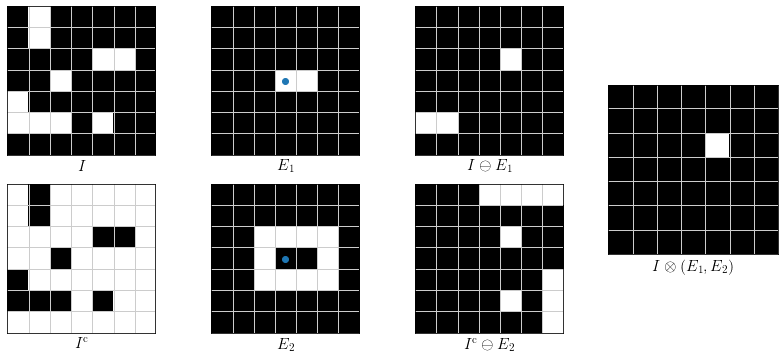

In [5]:
# Toy image
I = np.array([ \
    [0, 1, 0, 0, 0, 0, 0], \
    [0, 1, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 1, 1, 0], \
    [0, 0, 1, 0, 0, 0, 0], \
    [1, 0, 0, 0, 0, 0, 0], \
    [1, 1, 1, 0, 1, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0] ])
Ic = 1 - I

# Structuring element 1
# E1 = np.array([[1, 1]])
E1 = np.array([ \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 1, 1, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0] ])

# Structuring element 2
# E2 = np.array([ \
#     [1, 1, 1, 1],
#     [1, 0, 0, 1], \
#     [1, 1, 1, 1] ])
E2 = np.array([ \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 1, 1, 1, 1, 0], \
    [0, 0, 1, 0, 0, 1, 0], \
    [0, 0, 1, 1, 1, 1, 0], \
    [0, 0, 0, 0, 0, 0, 0], \
    [0, 0, 0, 0, 0, 0, 0] ])

fig = plt.figure(figsize=(14,6))

# Erosion
plt.subplot(2,4,1)
display(I, "$I$")
plt.subplot(2,4,2)
display(E1, "$E_1$", sec=(3,3))
plt.subplot(2,4,3)
display(mo.binary_erosion(I,E1), "$I \ominus E_1$")

# Erosion of the complement
plt.subplot(2,4,5)
display(Ic, "$I^\mathrm{c}$")
plt.subplot(2,4,6)
display(E2, "$E_2$", sec=(3,3))
plt.subplot(2,4,7)
display(mo.binary_erosion(Ic,E2), "$I^\mathrm{c} \ominus E_2$")

# Hit-or-miss
# I1 = mo.binary_erosion(I,E1)
# I2 = mo.binary_erosion(Ic,E2)
# U = np.bitwise_and(I1,I2)
# plt.subplot(3,3,8)
# display(U, "")
plt.subplot(1,4,4)
display(smo.binary_hit_or_miss(I,E1, E2), r"$I \otimes (E_1,E_2)$")

plt.savefig("hit-or-miss-toy.svg", bbox_inches='tight')

In [6]:
# Real image ans structuring element
img = io.imread("greece.png")
se = mo.disk(4)

from skimage import img_as_ubyte

io.imsave("greece-dilation.png", img_as_ubyte(mo.binary_dilation(img,se)))
io.imsave("greece-erosion.png",  img_as_ubyte(mo.binary_erosion(img,se) ))
io.imsave("greece-opening.png",  img_as_ubyte(mo.binary_opening(img,se) ))
io.imsave("greece-closing.png",  img_as_ubyte(mo.binary_closing(img,se) ))

# # Dilation & erosion
# fig = plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# display(img, "Binary image", grid=False)
# plt.subplot(1,3,2)
# display(mo.binary_dilation(img,se), "Dilation", grid=False)
# plt.subplot(1,3,3)
# display(mo.binary_erosion(img,se), "Erosion", grid=False)
# plt.savefig("real-dilation-erosion.svg")

# # Opening & closing
# fig = plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# display(img, "Binary image", grid=False)
# plt.subplot(1,3,2)
# display(mo.binary_opening(img,se), "Opening", grid=False)
# plt.subplot(1,3,3)
# display(mo.binary_closing(img,se), "Closing", grid=False)
# plt.savefig("real-opening-closing.svg")

# Measures

In [7]:
from skimage.measure import label, regionprops
import matplotlib as mpl
mpl.rcParams['xtick.bottom']      = False
mpl.rcParams['xtick.top']         = False
mpl.rcParams['xtick.labelbottom'] = False
mpl.rcParams['ytick.left']        = False
mpl.rcParams['ytick.right']       = False
mpl.rcParams['ytick.labelleft']   = False
mpl.rcParams['font.size']         = 16

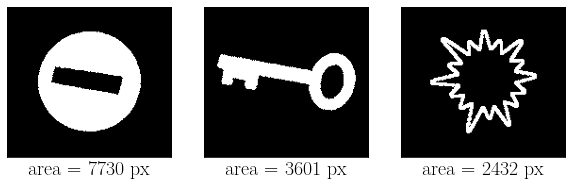

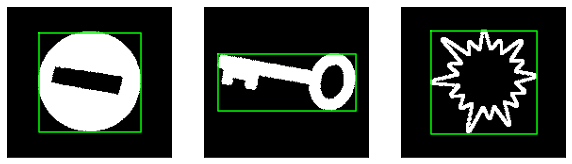

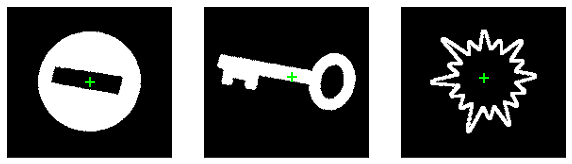

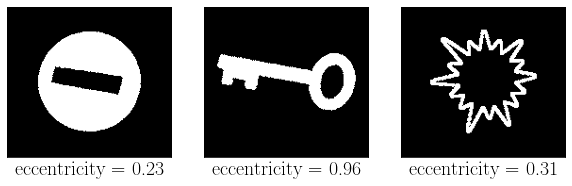

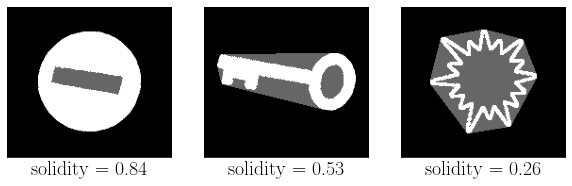

In [33]:
props = [ "area", "bbox", "centroid", "eccentricity", "solidity" ]
imgs = [ "noway", "key", "sun" ]
N = len(imgs)

for prop in props:
    
    fig, axs = plt.subplots(1,N, figsize=(10,5))
    for i in range(N):
        
        # Chargement et affichage de l'image
        img = io.imread(f'dobble-{imgs[i]}.png')
        axs[i].imshow(img, cmap="gray")
        
        properties = regionprops(img)[0]
    
        if prop == "area":
            axs[i].set_xlabel(f"area = {properties.area} px", size=20)
    
        if prop == "bbox":
            ymin, xmin, ymax, xmax = properties.bbox
            axs[i].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], '#00ff00')
    
        if prop == "centroid":
            y, x = properties.centroid
            axs[i].plot(x, y, color='#00ff00', marker='+', markersize=10, markeredgewidth=2)
    
        if prop == "eccentricity":
            axs[i].set_xlabel(f"eccentricity = {properties.eccentricity:.2f}", size=20)
    
        if prop == "solidity":
            ch = mo.convex_hull_image(img)
            ch = img_as_float(ch)
            ch[img>0] = 2.5
            axs[i].imshow(ch, cmap="gray")
            axs[i].set_xlabel(f"solidity = {properties.solidity:.2f}", size=20)
    
    plt.show()
    fig.savefig(f"prop-{prop}.svg", bbox_inches='tight')